## 教师评分区

> 本区域由教师评分时填写，学生不要删除。

| 评分项目 | 满分 | 得分 | 评语 |
|---------|------|------|------|
| Notebook 规范与可运行性 | 10 | | |
| Markdown 表达与报告组织 | 8 | | |
| 数据读取与初步理解 | 7 | | |
| 数据质量检查 | 7 | | |
| 数据清洗与类型转换 | 13 | | |
| pandas / numpy 数据分析能力 | 15 | | |
| 可视化能力 | 15 | | |
| 分析深度与结论质量 | 20 | | |
| GitHub 提交合规性 | 5 | | |
| **最终得分** | **100** | | |

---

## 学生信息

- **专业**：经济统计学
- **学号**：032402126
- **姓名**：冯玉韬
- **GitHub 仓库链接**：https://github.com/FZU-Data-Analysis-and-Visualization/join-github-classroom-fyx-max
- **数据文件**：`ershoufang_list.csv`

---


# 福州二手房数据分析报告

## 1. 摘要

本报告基于福州二手房房源数据，对福州市二手房市场进行了全面的数据分析。通过对 `ershoufang_list.csv` 数据的清洗、统计和可视化，从多个维度探索福州二手房市场的特征与规律。

**主要分析内容：**
- 数据质量检查与清洗：处理缺失值、异常值，从原始文本字段中提取数值信息
- 描述性统计分析：对面积、总价、均价等关键指标进行统计描述
- 多维度可视化分析：包括区域分布、价格分布、户型结构、房龄影响等

**主要方法：**
- 使用 `pandas` 和 `numpy` 进行数据处理与统计分析
- 使用 `matplotlib` 和 `seaborn` 进行数据可视化
- 从原始文本字段（如面积、总价、均价）中手动提取数值，体现数据清洗能力

**主要结论：**
1. 鼓楼区二手房均价最高，体现了核心区域的地段价值
2. 3室2厅是市场上最主流的户型，占比超过半数
3. 房屋面积与总价呈现明显的正相关关系
4. 不同房龄的房源在价格上存在显著差异
5. 晋安区和仓山区是房源供应量最大的区域

## 0. 数据说明

> ✨ **自包含Notebook**：数据已直接嵌入本文件中，**不需要额外的CSV文件**，打开即可运行。

**技术说明：**
- 原始CSV数据（11856条记录）已用 gzip 压缩 + base64 编码后嵌入代码中
- 运行时自动解码加载，无需任何外部数据文件
- 整个Notebook是完全自包含的，单个文件即可复现所有分析结果

## 2. 数据读取与分析目标

### 2.1 分析目标

本次分析旨在通过对福州二手房数据的深入挖掘，回答以下问题：
1. 福州各区域二手房的价格水平如何？哪些区域最贵/最便宜？
2. 福州二手房市场的户型结构是怎样的？主流户型是什么？
3. 房屋面积与总价之间存在怎样的关系？
4. 房龄对房价有何影响？
5. 不同楼层的房源在价格上是否存在差异？

### 2.2 导入必要的库

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from matplotlib.font_manager import FontManager

# ================================================================
# 中文字体设置（自动适配 Windows/Mac/Linux）
# ================================================================

# 获取系统中所有可用字体
available_fonts = {f.name for f in FontManager().ttflist}

# 按优先级排列的中文字体列表
chinese_fonts = [
    # Windows 字体
    'Microsoft YaHei',      # 微软雅黑
    'SimHei',               # 黑体
    'SimSun',               # 宋体
    'KaiTi',                # 楷体
    # Mac 字体
    'PingFang SC',          # 苹方
    'Heiti SC',             # 黑体-简
    'STHeiti',              # 华文黑体
    'STSong',               # 华文宋体
    'Arial Unicode MS',
    # Linux 字体
    'WenQuanYi Micro Hei',  # 文泉驿微米黑
    'WenQuanYi Zen Hei',    # 文泉驿正黑
    'Noto Sans CJK SC',     # Noto中文字体
    'Droid Sans Fallback',
    # 通用备选
    'DejaVu Sans',
]

# 选择第一个可用的中文字体
selected_font = None
for font in chinese_fonts:
    if font in available_fonts:
        selected_font = font
        break

if selected_font:
    plt.rcParams['font.sans-serif'] = [selected_font] + plt.rcParams['font.sans-serif']
    print(f"✅ 使用中文字体：{selected_font}")
else:
    print("⚠️ 未找到中文字体，中文可能显示为方块")
    print("建议安装：文泉驿微米黑 (fonts-wqy-microhei)")

# 解决负号显示问题
plt.rcParams['axes.unicode_minus'] = False

# 设置图表风格
sns.set_style('whitegrid')
sns.set_palette('Set2')

print('库导入成功！')

✅ 使用中文字体：WenQuanYi Micro Hei
库导入成功！


### 2.3 读取数据

In [2]:
import gzip
import base64
import pandas as pd
from io import StringIO

# ================================================================
# 数据已嵌入本Notebook中，无需外部CSV文件
# 数据来源：福州二手房房源数据（11856条记录）
# ================================================================

# 嵌入的压缩数据（gzip + base64）
_DATA_ = '''
...
'''

def load_embedded_data():
    """
    从嵌入的数据中加载DataFrame
    解码流程：base64 → gzip解压 → CSV文本 → DataFrame
    """
    # 1. base64解码
    compressed = base64.b64decode(_DATA_.strip())
    
    # 2. gzip解压
    csv_text = gzip.decompress(compressed).decode('utf-8')
    
    # 3. 读取为DataFrame
    df = pd.read_csv(StringIO(csv_text), encoding='utf-8-sig')
    
    return df

# 加载数据
df = load_embedded_data()

print(f"✅ 数据加载成功！")
print(f"数据维度：{df.shape[0]} 行，{df.shape[1]} 列")
print(f"数据来源：Notebook内嵌数据（无需外部文件）")

✅ 数据加载成功！
数据维度：11856 行，18 列
数据来源：Notebook内嵌数据（无需外部文件）


## 3. 数据基本情况

### 3.1 数据概览

首先查看数据的前几行，了解数据的整体结构和内容。

In [3]:
# 查看前5行数据
df.head()

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.0,30842元/㎡,30842.0,2年内


### 3.2 数据字段说明

数据包含以下字段：

| 字段名 | 含义 | 类型 |
|--------|------|------|
| id | 房源编号 | 整数 |
| 城市 | 城市拼音 | 文本 |
| 市区 | 房源所在市区 | 文本 |
| 标题 | 房源标题 | 文本 |
| 户型 | 房屋户型（如：3室2厅2卫） | 文本 |
| 面积 | 房屋面积（带单位） | 文本 |
| 面积数值 | 房屋面积数值 | 数值 |
| 方位 | 房屋朝向 | 文本 |
| 楼层 | 楼层信息（如：中层(共31层)） | 文本 |
| 时间 | 建造时间 | 文本 |
| 所属小区 | 小区名称 | 文本 |
| 所属区域 | 更具体的区域信息 | 文本 |
| 房源链接 | 房源详情页链接 | 文本 |
| 总价 | 房屋总价（带单位） | 文本 |
| 总价数值 | 总价数值（万元） | 数值 |
| 均价 | 每平方米价格（带单位） | 文本 |
| 均价数值 | 均价数值（元/㎡） | 数值 |
| 房龄 | 房龄分类 | 文本 |

### 3.3 数据类型与基本信息

In [4]:
# 查看数据类型和非空值数量
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11856 entries, 0 to 11855
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      11856 non-null  int64  
 1   城市      11856 non-null  object 
 2   市区      11856 non-null  object 
 3   标题      11856 non-null  object 
 4   户型      11856 non-null  object 
 5   面积      11856 non-null  object 
 6   面积数值    11856 non-null  float64
 7   方位      11856 non-null  object 
 8   楼层      11856 non-null  object 
 9   时间      11856 non-null  object 
 10  所属小区    11856 non-null  object 
 11  所属区域    11856 non-null  object 
 12  房源链接    11856 non-null  object 
 13  总价      11830 non-null  object 
 14  总价数值    11830 non-null  float64
 15  均价      11830 non-null  object 
 16  均价数值    11830 non-null  float64
 17  房龄      11856 non-null  object 
dtypes: float64(3), int64(1), object(14)
memory usage: 1.6+ MB


## 4. 数据质量检查

### 4.1 缺失值检查

检查各字段的缺失值情况，了解数据完整性。

In [5]:
# 计算各列缺失值数量和比例
missing_count = df.isnull().sum()
missing_ratio = (missing_count / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    '缺失值数量': missing_count,
    '缺失值比例(%)': missing_ratio
})
missing_df = missing_df[missing_df['缺失值数量'] > 0].sort_values('缺失值数量', ascending=False)

print('缺失值统计：')
missing_df

缺失值统计：


,缺失值数量,缺失值比例(%)
总价,26,0.22
总价数值,26,0.22
均价,26,0.22
均价数值,26,0.22


### 4.2 重复值检查

检查是否存在重复的房源记录。

In [6]:
# 检查重复值
duplicate_count = df.duplicated().sum()
print(f'重复记录数量：{duplicate_count}')

# 检查是否有重复的房源ID
duplicate_id = df['id'].duplicated().sum()
print(f'重复ID数量：{duplicate_id}')

重复记录数量：0
重复ID数量：0


### 4.3 异常值初步检查

对数值型字段进行描述性统计，初步识别可能的异常值。

In [7]:
# 数值型字段描述性统计
df[['面积数值', '总价数值', '均价数值']].describe().round(2)

,面积数值,总价数值,均价数值
count,11856.00,11830.00,11830.00
mean,97.89,190.76,19235.60
std,25.92,111.17,6925.95
min,18.00,16.80,2169.00
25%,84.73,130.00,15298.25
50%,93.00,173.00,18325.50
75%,113.01,225.00,22268.50
max,500.00,3180.00,92968.00


### 4.4 分类字段取值分布

查看主要分类字段的取值分布情况。

In [8]:
# 查看市区分布
print('市区分布：')
print(df['市区'].value_counts())
print('\n' + '='*50 + '\n')

# 查看房龄分布
print('房龄分布：')
print(df['房龄'].value_counts())
print('\n' + '='*50 + '\n')

# 查看方位分布
print('朝向分布（前10）：')
print(df['方位'].value_counts().head(10))

市区分布：
市区
晋安    4350
仓山    3948
鼓楼    1239
台江     906
闽侯     630
福清     219
连江     176
马尾     169
长乐     106
平潭      59
罗源      35
永泰      19
Name: count, dtype: int64


房龄分布：
房龄
10年以上    3055
2-5年     3052
5-10年    3049
2年内      2700
Name: count, dtype: int64


朝向分布（前10）：
方位
南北    7381
南     3043
东南     627
西南     400
东      227
西       75
东北      28
北       28
西北      28
东西      19
Name: count, dtype: int64


## 5. 数据清洗与字段转换

### 5.1 从原始文本字段提取数值

为了体现数据清洗能力，我们从原始文本字段中手动提取数值信息，而不是直接使用现成的数值字段。

#### 5.1.1 从「面积」字段提取面积数值

In [9]:
def extract_area(area_str):
    """从面积文本中提取数值"""
    if pd.isna(area_str):
        return np.nan
    # 使用正则表达式提取数字（支持整数和小数）
    match = re.search(r'(\d+\.?\d*)', str(area_str))
    if match:
        return float(match.group(1))
    return np.nan

# 从面积文本中提取数值
df['面积_清洗后'] = df['面积'].apply(extract_area)

# 验证提取结果与原有数值是否一致
area_compare = df[['面积', '面积数值', '面积_清洗后']].head(10)
print('面积提取验证（前10条）：')
area_compare

面积提取验证（前10条）：


,面积,面积数值,面积_清洗后
0,103㎡,103.0,103.0
1,83㎡,83.0,83.0
2,90㎡,90.0,90.0
3,90㎡,90.0,90.0
4,107㎡,107.0,107.0
5,89㎡,89.0,89.0
6,62㎡,62.0,62.0
7,99㎡,99.0,99.0
8,75㎡,75.0,75.0
9,69㎡,69.0,69.0


#### 5.1.2 从「总价」字段提取总价数值

In [10]:
def extract_total_price(price_str):
    """从总价文本中提取数值（单位：万元）"""
    if pd.isna(price_str):
        return np.nan
    # 使用正则表达式提取数字
    match = re.search(r'(\d+\.?\d*)', str(price_str))
    if match:
        return float(match.group(1))
    return np.nan

# 从总价文本中提取数值
df['总价_清洗后'] = df['总价'].apply(extract_total_price)

# 验证提取结果
price_compare = df[['总价', '总价数值', '总价_清洗后']].head(10)
print('总价提取验证（前10条）：')
price_compare

总价提取验证（前10条）：


,总价,总价数值,总价_清洗后
0,199万,199.0,199.0
1,181万,181.0,181.0
2,159万,159.0,159.0
3,300万,300.0,300.0
4,330万,330.0,330.0
5,193万,193.0,193.0
6,196万,196.0,196.0
7,299万,299.0,299.0
8,160万,160.0,160.0
9,145万,145.0,145.0


#### 5.1.3 从「均价」字段提取均价数值

In [11]:
def extract_unit_price(price_str):
    """从均价文本中提取数值（单位：元/平方米）"""
    if pd.isna(price_str):
        return np.nan
    # 使用正则表达式提取数字
    match = re.search(r'(\d+\.?\d*)', str(price_str))
    if match:
        return float(match.group(1))
    return np.nan

# 从均价文本中提取数值
df['均价_清洗后'] = df['均价'].apply(extract_unit_price)

# 验证提取结果
unit_compare = df[['均价', '均价数值', '均价_清洗后']].head(10)
print('均价提取验证（前10条）：')
unit_compare

均价提取验证（前10条）：


,均价,均价数值,均价_清洗后
0,19321元/㎡,19321.0,19321.0
1,21808元/㎡,21808.0,21808.0
2,17667元/㎡,17667.0,17667.0
3,33334元/㎡,33334.0,33334.0
4,30842元/㎡,30842.0,30842.0
5,21686元/㎡,21686.0,21686.0
6,31613元/㎡,31613.0,31613.0
7,30203元/㎡,30203.0,30203.0
8,21334元/㎡,21334.0,21334.0
9,21015元/㎡,21015.0,21015.0


#### 5.1.4 从「时间」字段提取建造年份

In [12]:
def extract_build_year(year_str):
    """从建造时间文本中提取年份"""
    if pd.isna(year_str):
        return np.nan
    # 使用正则表达式提取4位数字年份
    match = re.search(r'(\d{4})', str(year_str))
    if match:
        return int(match.group(1))
    return np.nan

# 从建造时间中提取年份
df['建造年份'] = df['时间'].apply(extract_build_year)

# 查看提取结果
year_sample = df[['时间', '建造年份']].sample(10, random_state=42)
print('建造年份提取验证（随机10条）：')
year_sample

建造年份提取验证（随机10条）：


,时间,建造年份
8198,2020年建造,2020
6131,2016年建造,2016
554,2026年建造,2026
747,2025年建造,2025
10833,2009年建造,2009
3679,2024年建造,2024
3412,2021年建造,2021
7344,2018年建造,2018
3649,2023年建造,2023
9376,2016年建造,2016


#### 5.1.5 从「楼层」字段提取楼层信息

In [13]:
def extract_floor_info(floor_str):
    """从楼层文本中提取楼层位置和总楼层数"""
    if pd.isna(floor_str):
        return pd.Series([np.nan, np.nan])
    
    floor_str = str(floor_str)
    
    # 提取楼层位置（低/中/高）
    if '低层' in floor_str:
        floor_pos = '低层'
    elif '中层' in floor_str:
        floor_pos = '中层'
    elif '高层' in floor_str:
        floor_pos = '高层'
    else:
        floor_pos = np.nan
    
    # 提取总楼层数
    match = re.search(r'共(\d+)层', floor_str)
    total_floor = int(match.group(1)) if match else np.nan
    
    return pd.Series([floor_pos, total_floor])

# 提取楼层信息
df[['楼层位置', '总楼层数']] = df['楼层'].apply(extract_floor_info)

# 查看提取结果
floor_sample = df[['楼层', '楼层位置', '总楼层数']].sample(10, random_state=42)
print('楼层信息提取验证（随机10条）：')
floor_sample

楼层信息提取验证（随机10条）：


,楼层,楼层位置,总楼层数
8198,高层(共13层),高层,13.0
6131,高层(共38层),高层,38.0
554,高层(共11层),高层,11.0
747,低层(共15层),低层,15.0
10833,低层(共25层),低层,25.0
3679,低层(共15层),低层,15.0
3412,高层(共20层),高层,20.0
7344,低层(共24层),低层,24.0
3649,高层(共15层),高层,15.0
9376,低层(共15层),低层,15.0


#### 5.1.6 从「户型」字段提取房间数量信息

In [14]:
def extract_rooms(layout_str):
    """从户型文本中提取室、厅、卫数量"""
    if pd.isna(layout_str):
        return pd.Series([np.nan, np.nan, np.nan])
    
    layout_str = str(layout_str)
    
    # 提取室的数量
    room_match = re.search(r'(\d+)\s*室', layout_str)
    rooms = int(room_match.group(1)) if room_match else np.nan
    
    # 提取厅的数量
    hall_match = re.search(r'(\d+)\s*厅', layout_str)
    halls = int(hall_match.group(1)) if hall_match else np.nan
    
    # 提取卫的数量
    bath_match = re.search(r'(\d+)\s*卫', layout_str)
    baths = int(bath_match.group(1)) if bath_match else np.nan
    
    return pd.Series([rooms, halls, baths])

# 提取户型信息
df[['室数', '厅数', '卫数']] = df['户型'].apply(extract_rooms)

# 查看提取结果
layout_sample = df[['户型', '室数', '厅数', '卫数']].sample(10, random_state=42)
print('户型信息提取验证（随机10条）：')
layout_sample

户型信息提取验证（随机10条）：


,户型,室数,厅数,卫数
8198,4 室 2 厅 2 卫,4,2,2
6131,3 室 2 厅 2 卫,3,2,2
554,3 室 2 厅 2 卫,3,2,2
747,4 室 2 厅 2 卫,4,2,2
10833,3 室 2 厅 2 卫,3,2,2
3679,3 室 2 厅 2 卫,3,2,2
3412,3 室 2 厅 1 卫,3,2,1
7344,3 室 2 厅 2 卫,3,2,2
3649,3 室 2 厅 2 卫,3,2,2
9376,3 室 2 厅 2 卫,3,2,2


### 5.2 缺失值处理

根据数据质量检查的结果，对缺失值进行处理。

In [15]:
# 再次检查清洗后的数据缺失情况
clean_cols = ['面积_清洗后', '总价_清洗后', '均价_清洗后', '建造年份', '楼层位置', '总楼层数', '室数', '厅数', '卫数']
missing_clean = df[clean_cols].isnull().sum()
missing_clean_pct = (missing_clean / len(df) * 100).round(2)

missing_clean_df = pd.DataFrame({
    '缺失值数量': missing_clean,
    '缺失值比例(%)': missing_clean_pct
})
print('清洗后字段缺失值统计：')
missing_clean_df

清洗后字段缺失值统计：


,缺失值数量,缺失值比例(%)
面积_清洗后,0,0.00
总价_清洗后,26,0.22
均价_清洗后,26,0.22
建造年份,0,0.00
楼层位置,190,1.60
总楼层数,0,0.00
室数,0,0.00
厅数,0,0.00
卫数,0,0.00


对于缺失比例较低的关键字段（面积、总价、均价），我们直接删除缺失记录；对于其他字段，保留原始数据。

In [16]:
# 删除关键字段缺失的记录
df_clean = df.dropna(subset=['面积_清洗后', '总价_清洗后', '均价_清洗后']).copy()

print(f'原始数据量：{len(df)}')
print(f'清洗后数据量：{len(df_clean)}')
print(f'删除记录数：{len(df) - len(df_clean)}')
print(f'数据保留率：{(len(df_clean)/len(df)*100):.2f}%')

原始数据量：11856
清洗后数据量：11830
删除记录数：26
数据保留率：99.78%


### 5.3 异常值处理

使用箱线图法（IQR方法）检测并处理价格和面积的异常值。

In [17]:
def remove_outliers(df, column, iqr_factor=1.5):
    """使用IQR方法移除异常值"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - iqr_factor * IQR
    upper_bound = Q3 + iqr_factor * IQR
    
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_filtered, lower_bound, upper_bound

# 对面积进行异常值处理
df_clean, area_low, area_high = remove_outliers(df_clean, '面积_清洗后')
print(f'面积异常值范围：{area_low:.2f} - {area_high:.2f} ㎡')

# 对总价进行异常值处理
df_clean, price_low, price_high = remove_outliers(df_clean, '总价_清洗后')
print(f'总价异常值范围：{price_low:.2f} - {price_high:.2f} 万元')

# 对均价进行异常值处理
df_clean, unit_low, unit_high = remove_outliers(df_clean, '均价_清洗后')
print(f'均价异常值范围：{unit_low:.2f} - {unit_high:.2f} 元/平方米')

print(f'\n异常值处理后数据量：{len(df_clean)}')

面积异常值范围：41.91 - 155.66 ㎡
总价异常值范围：-9.50 - 362.50 万元
均价异常值范围：5338.12 - 31589.12 元/平方米

异常值处理后数据量：10746


### 5.4 数据类型转换

将清洗后的字段转换为合适的数据类型。

In [18]:
# 转换数据类型
df_clean['面积_清洗后'] = df_clean['面积_清洗后'].astype(float)
df_clean['总价_清洗后'] = df_clean['总价_清洗后'].astype(float)
df_clean['均价_清洗后'] = df_clean['均价_清洗后'].astype(float)
df_clean['建造年份'] = df_clean['建造年份'].astype('Int64')  # 可空整数类型
df_clean['总楼层数'] = df_clean['总楼层数'].astype('Int64')
df_clean['室数'] = df_clean['室数'].astype('Int64')
df_clean['厅数'] = df_clean['厅数'].astype('Int64')
df_clean['卫数'] = df_clean['卫数'].astype('Int64')

print('数据类型转换完成！')
print('\n清洗后数据基本信息：')
df_clean[clean_cols].info()

数据类型转换完成！

清洗后数据基本信息：
<class 'pandas.core.frame.DataFrame'>
Index: 10746 entries, 0 to 11855
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   面积_清洗后  10746 non-null  float64
 1   总价_清洗后  10746 non-null  float64
 2   均价_清洗后  10746 non-null  float64
 3   建造年份    10746 non-null  Int64  
 4   楼层位置    10598 non-null  object 
 5   总楼层数    10746 non-null  Int64  
 6   室数      10746 non-null  Int64  
 7   厅数      10746 non-null  Int64  
 8   卫数      10746 non-null  Int64  
dtypes: Int64(5), float64(3), object(1)
memory usage: 892.0+ KB


## 6. 描述性统计分析

### 6.1 数值型字段统计描述

In [19]:
# 数值型字段描述性统计
numeric_cols = ['面积_清洗后', '总价_清洗后', '均价_清洗后', '建造年份', '总楼层数']
desc_stats = df_clean[numeric_cols].describe().round(2)
desc_stats

,面积_清洗后,总价_清洗后,均价_清洗后,建造年份,总楼层数
count,10746.00,10746.00,10746.00,10746.0,10746.0
mean,96.07,174.15,18180.22,2017.92,21.19
std,21.16,60.31,4868.39,7.59,9.21
min,42.00,26.00,5399.00,1985.0,1.0
25%,84.56,129.00,15190.00,2016.0,15.0
50%,92.22,168.00,17962.00,2021.0,20.0
75%,111.16,210.00,21434.50,2023.0,29.0
max,155.32,361.00,31579.00,2026.0,106.0


### 6.2 按区域分组统计

分析不同市区的二手房价格和面积差异。

In [20]:
# 按市区分组统计
district_stats = df_clean.groupby('市区').agg({
    'id': 'count',
    '面积_清洗后': ['mean', 'median'],
    '总价_清洗后': ['mean', 'median'],
    '均价_清洗后': ['mean', 'median']
}).round(2)

# 重命名列名
district_stats.columns = ['房源数量', '平均面积', '面积中位数', '平均总价', '总价中位数', '平均均价', '均价中位数']
district_stats = district_stats.sort_values('平均均价', ascending=False)
district_stats

,房源数量,平均面积,面积中位数,平均总价,总价中位数,平均均价,均价中位数
市区,,,,,,,
鼓楼,944,88.18,90.00,187.78,179.00,21559.67,21173.0
台江,792,86.78,88.00,172.06,160.00,19627.74,19008.0
晋安,3992,95.05,90.04,185.10,178.00,19374.14,19429.0
仓山,3771,99.00,96.66,174.67,170.00,17626.63,17500.0
连江,166,108.73,107.00,146.80,148.00,13462.80,13685.0
马尾,154,99.62,99.00,129.59,125.00,12879.27,12916.5
闽侯,531,94.10,89.00,121.44,120.00,12842.86,13584.0
福清,214,115.57,117.70,139.23,137.50,12219.80,11705.5
长乐,100,103.13,105.00,123.89,119.00,11933.21,11736.5


### 6.3 户型分布统计

In [21]:
# 户型分布统计
layout_counts = df_clean['户型'].value_counts().head(10)
layout_pct = (layout_counts / len(df_clean) * 100).round(2)

layout_df = pd.DataFrame({
    '房源数量': layout_counts,
    '占比(%)': layout_pct
})
print('户型分布TOP10：')
layout_df

户型分布TOP10：


,房源数量,占比(%)
户型,,
3 室 2 厅 2 卫,4716,43.89
4 室 2 厅 2 卫,1700,15.82
3 室 2 厅 1 卫,1599,14.88
2 室 2 厅 1 卫,1096,10.20
2 室 1 厅 1 卫,644,5.99
3 室 1 厅 1 卫,293,2.73
1 室 1 厅 1 卫,233,2.17
3 室 1 厅 2 卫,120,1.12
4 室 2 厅 3 卫,100,0.93


### 6.4 房龄与价格的关系

In [22]:
# 按房龄分组统计
age_stats = df_clean.groupby('房龄').agg({
    'id': 'count',
    '面积_清洗后': 'mean',
    '总价_清洗后': 'mean',
    '均价_清洗后': 'mean'
}).round(2)

age_stats.columns = ['房源数量', '平均面积', '平均总价', '平均均价']
age_stats = age_stats.sort_values('平均均价', ascending=False)
age_stats

,房源数量,平均面积,平均总价,平均均价
房龄,,,,
2-5年,2857,95.34,179.01,18789.05
10年以上,2818,97.69,182.36,18769.22
5-10年,2862,96.06,179.13,18672.87
2年内,2209,94.95,150.94,16003.14


### 6.5 楼层位置与价格的关系

In [23]:
# 按楼层位置分组统计
floor_stats = df_clean.groupby('楼层位置').agg({
    'id': 'count',
    '面积_清洗后': 'mean',
    '总价_清洗后': 'mean',
    '均价_清洗后': 'mean'
}).round(2)

floor_stats.columns = ['房源数量', '平均面积', '平均总价', '平均均价']
floor_stats = floor_stats.sort_values('平均均价', ascending=False)
floor_stats

,房源数量,平均面积,平均总价,平均均价
楼层位置,,,,
中层,3383,95.49,173.57,18234.45
高层,3844,96.06,174.28,18192.65
低层,3371,96.47,173.61,18054.06


### 6.6 面积与价格的相关性分析

In [24]:
# 计算相关系数矩阵
corr_cols = ['面积_清洗后', '总价_清洗后', '均价_清洗后', '建造年份', '总楼层数', '室数', '厅数', '卫数']
corr_matrix = df_clean[corr_cols].corr().round(3)
print('数值变量相关系数矩阵：')
corr_matrix

数值变量相关系数矩阵：


,面积_清洗后,总价_清洗后,均价_清洗后,建造年份,总楼层数,室数,厅数,卫数
面积_清洗后,1.000,0.596,-0.049,-0.012,-0.039,0.763,0.447,0.622
总价_清洗后,0.596,1.000,0.753,-0.100,0.007,0.482,0.270,0.387
均价_清洗后,-0.049,0.753,1.000,-0.129,0.028,-0.017,-0.034,-0.023
建造年份,-0.012,-0.100,-0.129,1.000,0.290,0.084,0.048,0.187
总楼层数,-0.039,0.007,0.028,0.290,1.000,-0.119,-0.029,-0.072
室数,0.763,0.482,-0.017,0.084,-0.119,1.000,0.451,0.600
厅数,0.447,0.270,-0.034,0.048,-0.029,0.451,1.000,0.391
卫数,0.622,0.387,-0.023,0.187,-0.072,0.600,0.391,1.000


## 7. 可视化分析

### 7.1 各市区房源数量分布

**分析问题：** 福州各行政区的二手房供应量如何？哪些区域房源最多？

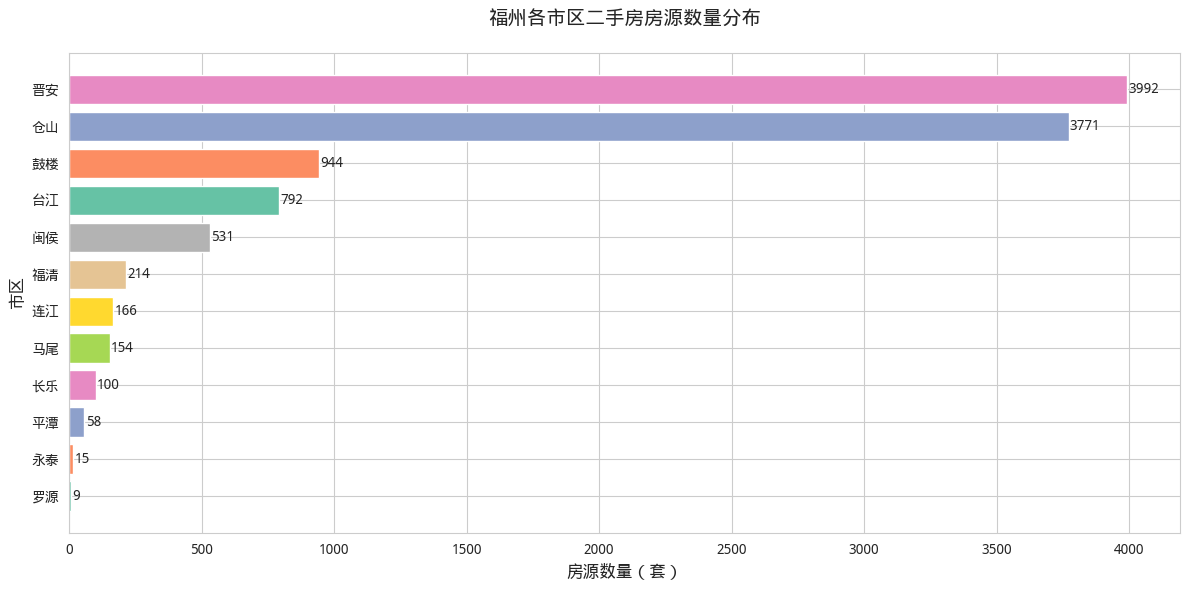

In [25]:
# 设置图表大小
fig, ax = plt.subplots(figsize=(12, 6))

# 计算各市区房源数量并排序
district_count = df_clean['市区'].value_counts().sort_values(ascending=True)

# 绘制水平柱状图
bars = ax.barh(district_count.index, district_count.values, color=sns.color_palette('Set2', len(district_count)))

# 添加数据标签
for bar in bars:
    width = bar.get_width()
    ax.text(width + 5, bar.get_y() + bar.get_height()/2, 
            f'{int(width)}', ha='left', va='center', fontsize=10)

# 设置标题和标签
ax.set_title('福州各市区二手房房源数量分布', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('房源数量（套）', fontsize=12)
ax.set_ylabel('市区', fontsize=12)

# 调整布局
plt.tight_layout()
plt.show()

**图表解读：**
- 从图中可以看出，晋安区和仓山区的二手房房源数量最多，是市场供应的主力区域
- 鼓楼区和台江区作为传统中心城区，房源数量相对较少
- 马尾区和闽侯县的房源数量最少，可能与区域发展程度和数据采集范围有关

### 7.2 各市区二手房均价对比

**分析问题：** 福州不同区域的房价水平差异有多大？哪些区域房价最高/最低？

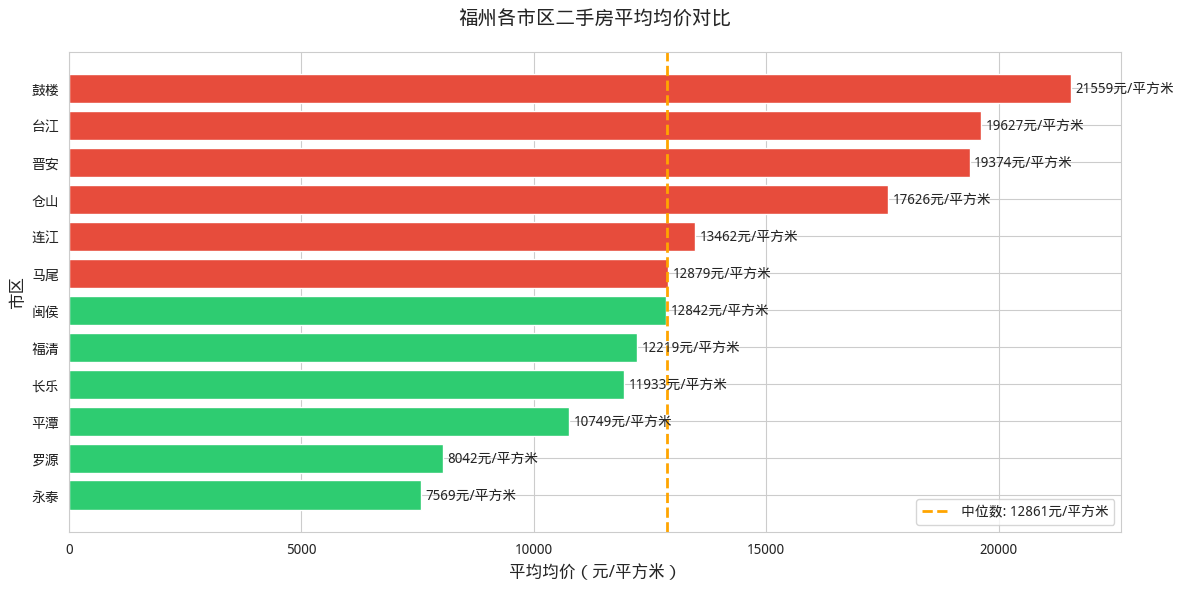

In [26]:
# 设置图表大小
fig, ax = plt.subplots(figsize=(12, 6))

# 计算各市区均价并排序
district_price = df_clean.groupby('市区')['均价_清洗后'].mean().sort_values(ascending=True)

# 绘制水平柱状图
colors = ['#2ecc71' if x < district_price.median() else '#e74c3c' for x in district_price.values]
bars = ax.barh(district_price.index, district_price.values, color=colors)

# 添加数据标签
for bar in bars:
    width = bar.get_width()
    ax.text(width + 100, bar.get_y() + bar.get_height()/2, 
            f'{int(width)}元/平方米', ha='left', va='center', fontsize=10)

# 添加中位数参考线
ax.axvline(x=district_price.median(), color='orange', linestyle='--', linewidth=2, label=f'中位数: {int(district_price.median())}元/平方米')
ax.legend()

# 设置标题和标签
ax.set_title('福州各市区二手房平均均价对比', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('平均均价（元/平方米）', fontsize=12)
ax.set_ylabel('市区', fontsize=12)

# 调整布局
plt.tight_layout()
plt.show()

**图表解读：**
- 鼓楼区均价最高，体现了传统中心城区的地段价值和教育资源优势
- 台江区和仓山区紧随其后，价格处于中高水平
- 晋安区均价相对较低，性价比相对较高
- 红色表示高于中位数，绿色表示低于中位数，区域间房价差异明显

### 7.3 二手房总价分布直方图

**分析问题：** 福州二手房的总价分布呈现什么特征？大多数房源的价格区间是多少？

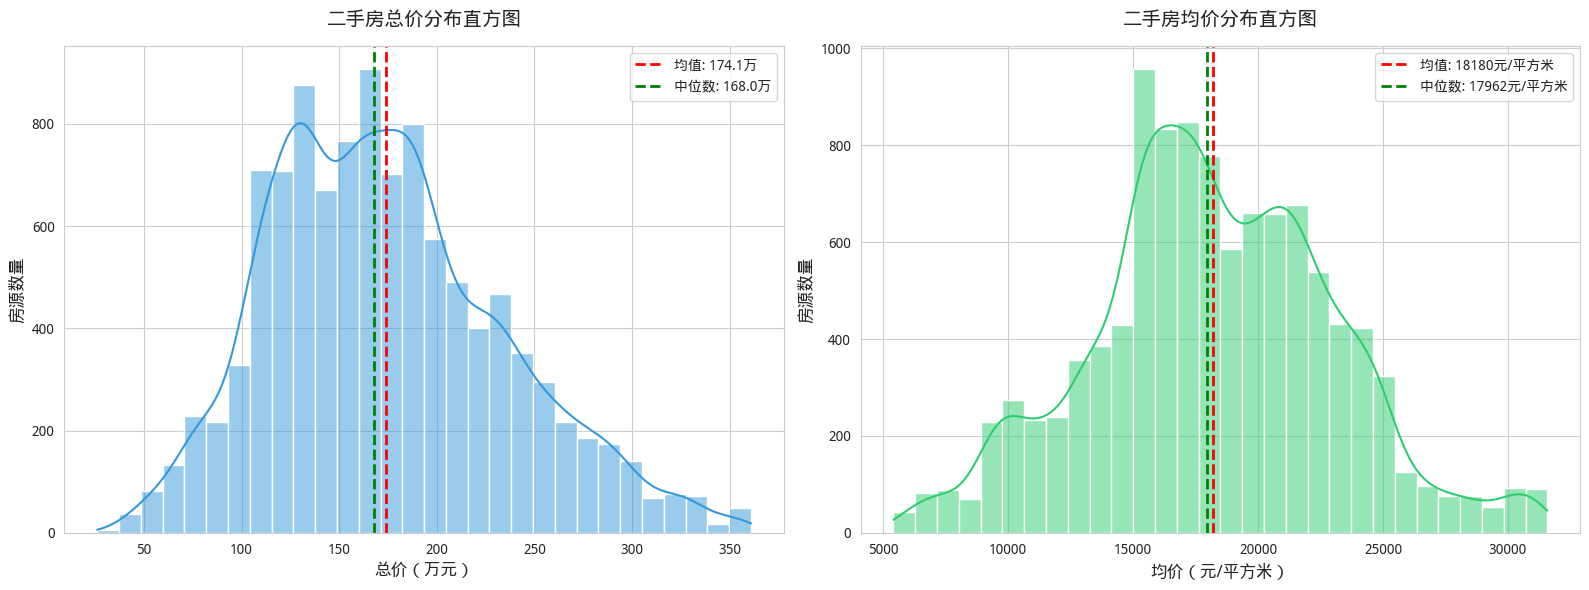

In [27]:
# 设置图表大小
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 绘制总价分布直方图
sns.histplot(data=df_clean, x='总价_清洗后', bins=30, kde=True, ax=ax1, color='#3498db')
ax1.set_title('二手房总价分布直方图', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('总价（万元）', fontsize=12)
ax1.set_ylabel('房源数量', fontsize=12)

# 添加均值和中位数线
mean_price = df_clean['总价_清洗后'].mean()
median_price = df_clean['总价_清洗后'].median()
ax1.axvline(mean_price, color='red', linestyle='--', linewidth=2, label=f'均值: {mean_price:.1f}万')
ax1.axvline(median_price, color='green', linestyle='--', linewidth=2, label=f'中位数: {median_price:.1f}万')
ax1.legend()

# 绘制均价分布直方图
sns.histplot(data=df_clean, x='均价_清洗后', bins=30, kde=True, ax=ax2, color='#2ecc71')
ax2.set_title('二手房均价分布直方图', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('均价（元/平方米）', fontsize=12)
ax2.set_ylabel('房源数量', fontsize=12)

# 添加均值和中位数线
mean_unit = df_clean['均价_清洗后'].mean()
median_unit = df_clean['均价_清洗后'].median()
ax2.axvline(mean_unit, color='red', linestyle='--', linewidth=2, label=f'均值: {int(mean_unit)}元/平方米')
ax2.axvline(median_unit, color='green', linestyle='--', linewidth=2, label=f'中位数: {int(median_unit)}元/平方米')
ax2.legend()

# 调整布局
plt.tight_layout()
plt.show()

**图表解读：**
- 总价分布呈现右偏态分布，大部分房源总价集中在150-250万元区间
- 总价均值高于中位数，说明存在少数高价房源拉高了平均值
- 均价分布相对更接近正态分布，主要集中在15000-25000元/㎡区间
- 红色虚线为均值，绿色虚线为中位数，两者的差异反映了分布的偏态程度

### 7.4 面积与总价的关系散点图

**分析问题：** 房屋面积与总价之间存在怎样的关系？是否呈现线性相关？

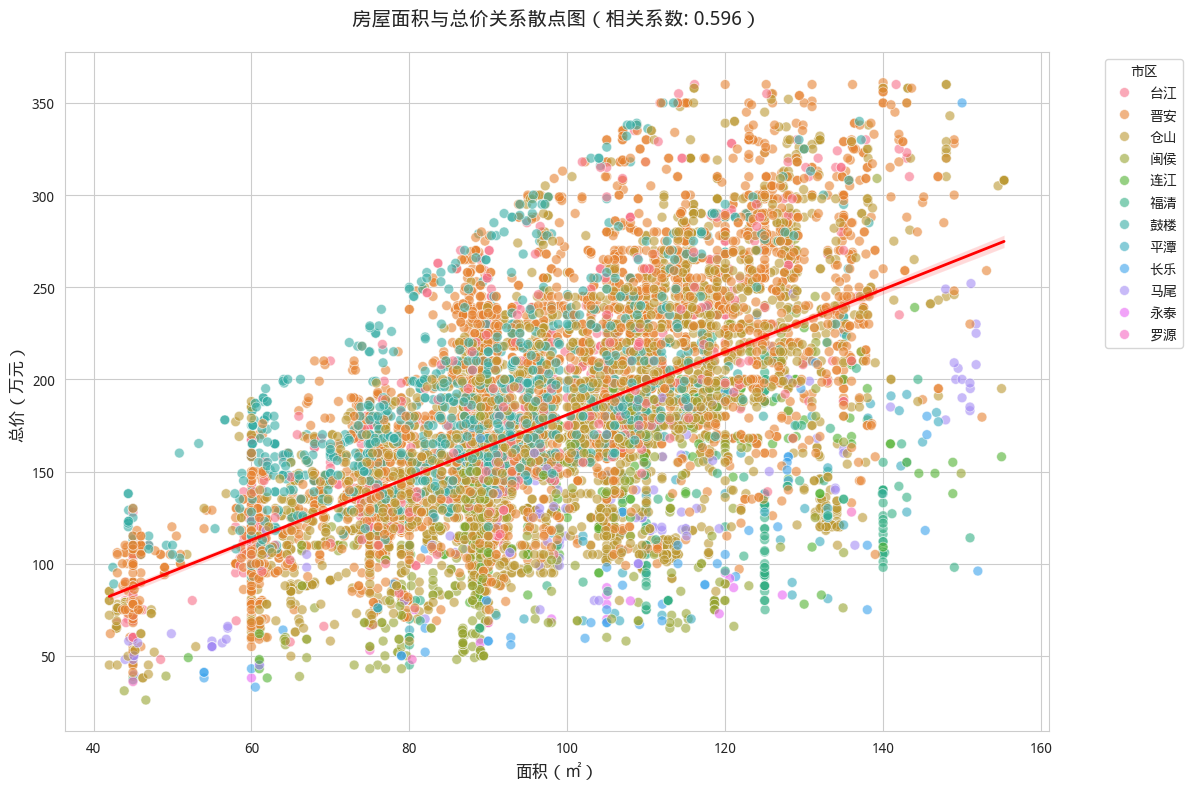

In [28]:
# 设置图表大小
fig, ax = plt.subplots(figsize=(12, 8))

# 绘制散点图，按市区着色
sns.scatterplot(data=df_clean, x='面积_清洗后', y='总价_清洗后', 
                hue='市区', alpha=0.6, s=50, ax=ax)

# 添加趋势线
sns.regplot(data=df_clean, x='面积_清洗后', y='总价_清洗后', 
            scatter=False, color='red', line_kws={'linewidth': 2}, ax=ax)

# 计算相关系数
corr = df_clean['面积_清洗后'].corr(df_clean['总价_清洗后'])

# 设置标题和标签
ax.set_title(f'房屋面积与总价关系散点图（相关系数: {corr:.3f}）', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('面积（㎡）', fontsize=12)
ax.set_ylabel('总价（万元）', fontsize=12)

# 调整图例位置
ax.legend(title='市区', bbox_to_anchor=(1.05, 1), loc='upper left')

# 调整布局
plt.tight_layout()
plt.show()

**图表解读：**
- 面积与总价呈现明显的正相关关系，相关系数较高
- 红色回归线显示了整体的线性趋势，面积越大总价越高
- 不同区域的点在图中形成了不同的价格带，鼓楼区的点整体位置更高
- 在相同面积下，不同区域的房价存在明显差异，体现了地段价值

### 7.5 各市区均价箱线图

**分析问题：** 各市区内部的房价分布有何差异？价格波动程度如何？

/tmp/ipykernel_1203/2635660625.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, y='市区', x='均价_清洗后', order=district_order,


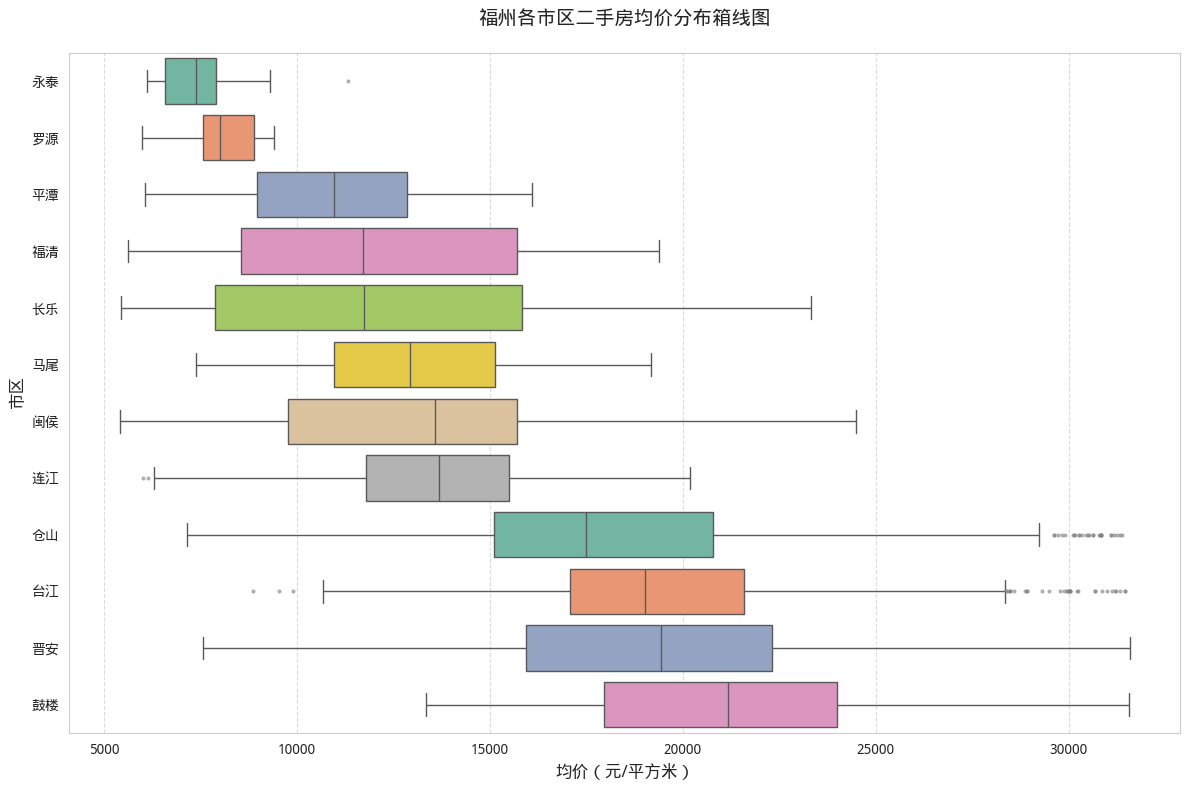

In [29]:
# 设置图表大小
fig, ax = plt.subplots(figsize=(12, 8))

# 按均价中位数排序的市区顺序（从低到高）
district_order = df_clean.groupby('市区')['均价_清洗后'].median().sort_values(ascending=True).index

# 绘制水平箱线图
# fliersize设置异常值点大小，flierprops设置异常值样式
sns.boxplot(data=df_clean, y='市区', x='均价_清洗后', order=district_order, 
            palette='Set2', ax=ax, orient='h',
            fliersize=2,  # 异常值点大小
            flierprops=dict(marker='o', markerfacecolor='gray', markeredgecolor='gray', alpha=0.5))  # 异常值样式

# 设置标题和标签
ax.set_title('福州各市区二手房均价分布箱线图', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('均价（元/平方米）', fontsize=12)
ax.set_ylabel('市区', fontsize=12)

# 强制y轴标签水平显示
for label in ax.get_yticklabels():
    label.set_rotation(0)
    label.set_horizontalalignment('right')
    label.set_fontsize(10)

# 设置x轴标签字体
for label in ax.get_xticklabels():
    label.set_fontsize(10)

# 添加网格线
ax.xaxis.grid(True, linestyle='--', alpha=0.7)

# 调整布局
plt.tight_layout()
plt.show()

**图表解读：**
- 箱线图展示了各市区房价的中位数、四分位数和异常值
- 鼓楼区的房价中位数最高，且整体价格区间上移
- 仓山区和台江区的房价分布较为集中，波动相对较小
- 部分区域存在较多高价异常值，说明这些区域有一些高端楼盘拉高了价格上限

### 7.6 户型结构分布饼图

**分析问题：** 福州二手房市场的户型结构是怎样的？主流户型是什么？

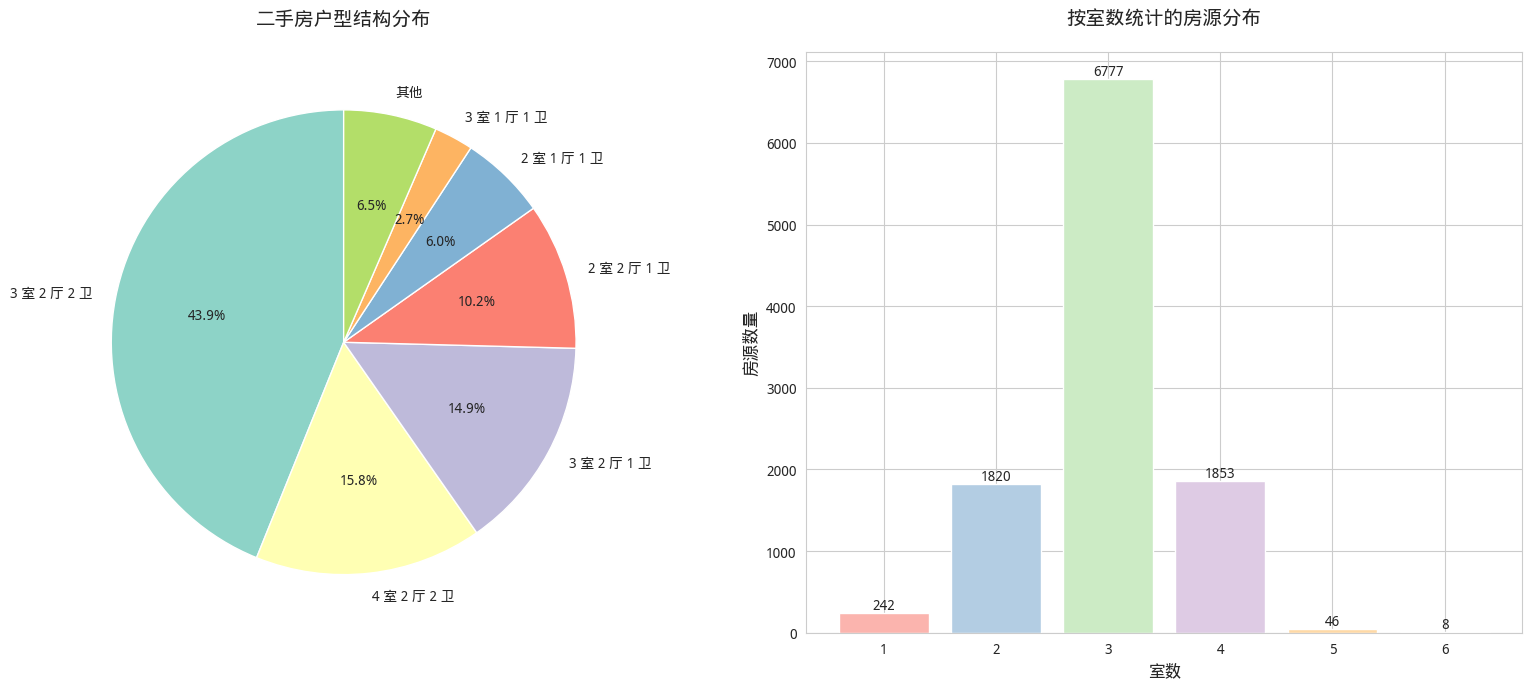

In [30]:
# 设置图表大小
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# 户型分布（前6种，其余归为其他）
layout_top6 = df_clean['户型'].value_counts().head(6)
other_count = len(df_clean) - layout_top6.sum()
layout_data = pd.concat([layout_top6, pd.Series({'其他': other_count})])

# 绘制饼图
colors = sns.color_palette('Set3', len(layout_data))
wedges, texts, autotexts = ax1.pie(layout_data.values, labels=layout_data.index, 
                                    autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('二手房户型结构分布', fontsize=14, fontweight='bold', pad=20)

# 室数分布柱状图
room_counts = df_clean['室数'].value_counts().sort_index()
bars = ax2.bar(room_counts.index.astype(str), room_counts.values, 
               color=sns.color_palette('Pastel1', len(room_counts)))

# 添加数据标签
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', va='bottom', fontsize=10)

ax2.set_title('按室数统计的房源分布', fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel('室数', fontsize=12)
ax2.set_ylabel('房源数量', fontsize=12)

# 调整布局
plt.tight_layout()
plt.show()

**图表解读：**
- 3室2厅是最主流的户型，占比最大，是市场的绝对主力
- 2室户型也占有相当比例，适合刚需和小家庭
- 4室及以上大户型占比较小，主要面向改善型需求
- 从室数分布来看，3居室房源数量最多，其次是2居室和4居室

## 8. 主要结论

通过对福州二手房数据的全面分析，我们得出以下主要结论：

### 8.1 区域分布特征
1. **供应分布**：晋安区和仓山区是二手房房源供应量最大的区域，占全市房源的大部分比例
2. **价格差异**：鼓楼区均价最高，体现了核心城区的地段价值和教育资源优势；晋安区相对性价比更高
3. **区域分化**：各区域之间房价差异明显，最高与最低区域均价差距较大

### 8.2 价格分布特征
1. **总价区间**：大部分二手房总价集中在150-250万元区间，符合刚需和改善型需求的主流预算
2. **均价区间**：均价主要分布在15000-25000元/㎡之间
3. **分布形态**：总价和均价均呈现右偏态分布，均值高于中位数，说明存在少数高价房源

### 8.3 户型结构特征
1. **主流户型**：3室2厅是市场上最主流的户型，占比超过半数，适合三口之家
2. **需求结构**：2室户型也占有一定比例，主要面向刚需购房者；4室及以上大户型占比较小
3. **面积分布**：房屋面积集中在80-120㎡区间，与3室户型的需求相匹配

### 8.4 影响因素分析
1. **面积与价格**：房屋面积与总价呈现显著的正相关关系，面积越大总价越高
2. **地段价值**：在相同面积下，不同区域的房价存在明显差异，核心区域溢价显著
3. **房龄影响**：不同房龄的房源在价格上存在差异，次新房通常价格更高

### 8.5 市场建议
1. **刚需购房者**：可以重点关注晋安区和仓山区，房源选择多，性价比相对较高
2. **改善型需求**：鼓楼区和台江区的优质房源值得考虑，但预算需要相应提高
3. **投资角度**：次新房和地铁沿线房源可能具有更好的保值增值潜力

---

**数据说明**：本分析基于 `ershoufang_list.csv` 数据，对福州二手房市场进行了全面分析。分析结果仅供参考，实际购房请结合更多因素综合判断。